# 01 — Quickstart

This notebook demonstrates the minimum workflow for loading a MagSIMS main analysis file,
plotting a spectrum, detecting peaks, assigning tentative isotope labels, and displaying a
processed FPD image export.

Expected example data location:

```text
data/
├── FPD_01_2604281458290.csv
├── FPD_01_2604281458290.raw
├── FPD_image2.csv
└── FPD_image2.raw
```

In [6]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pymagsims import spectrum
from pymagsims.spectrum import Spectrum
from pymagsims.isotopes import load_builtin_isotopes
from pymagsims.plotting import plot_ion_image, plot_ion_image_grid

DATA = Path("../tests/data")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load and plot a mass spectrum

dict_keys(['file_information', 'analysis_parameters', 'sims_metrics', 'platform_metrics'])
   Channel      Mass  Amplitude
0        1  1.700559        6.0
1        2  1.703664        8.0
2        3  1.706771        7.0
3        4  1.709879        8.0
4        5  1.712990       10.0


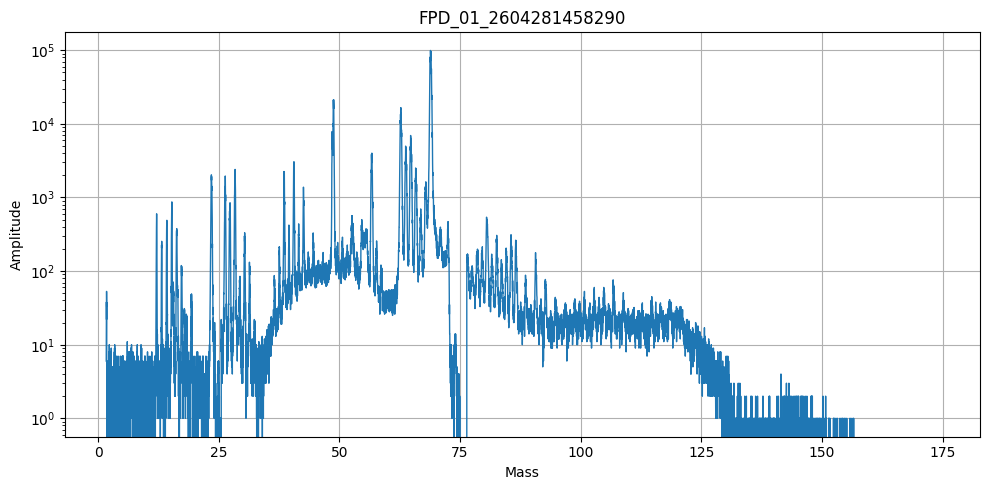

In [7]:
spec = Spectrum.from_main_analysis_file(DATA / "FPD_01_2604281458290.csv")

print(spec.metadata.keys())
print(spec.data.head())

fig, ax = spec.plot(log_y=True)

## Detect and assign peaks

In [8]:
isotopes = load_builtin_isotopes()

peaks = spec.find_peaks(prominence=100, distance=5)
assignments = spec.assign_peaks(
    isotope_table=isotopes,
    tolerance=0.2,
    prominence=100,
    distance=5,
)

display(peaks.head())
display(assignments.head(20))

,Channel,measured_mass,intensity,peak_index,prominences,left_bases,right_bases
0,2070,12.142001,600.0,2069,600.0,2030,2177
1,2218,13.196964,254.0,2217,254.0,2177,2269
2,2362,14.262894,490.0,2361,489.0,2318,2402
3,2497,15.297566,871.0,2496,871.0,2318,2681
4,2624,16.302165,378.0,2623,376.0,2586,2681


,measured_mass,intensity,element,isotope,exact_mass,abundance,mass_error,abs_mass_error
0,12.142001,600.0,C,12C,12.000000,98.930,0.142001,0.142001
1,13.196964,254.0,C,13C,13.003355,1.070,0.193609,0.193609
2,56.742039,4005.0,Fe,57Fe,56.935393,2.119,-0.193354,0.193354
3,56.830325,2284.0,Fe,57Fe,56.935393,2.119,-0.105068,0.105068
4,56.918679,867.0,Fe,57Fe,56.935393,2.119,-0.016714,0.016714
5,62.744836,16600.0,Cu,63Cu,62.929598,69.150,-0.184762,0.184762
6,62.868545,8321.0,Cu,63Cu,62.929598,69.150,-0.061053,0.061053
7,62.992374,2749.0,Cu,63Cu,62.929598,69.150,0.062776,0.062776
8,63.737871,4989.0,Zn,64Zn,63.929142,49.170,-0.191271,0.191271
9,63.831363,4716.0,Zn,64Zn,63.929142,49.170,-0.097779,0.097779


## Plot with labelled peaks

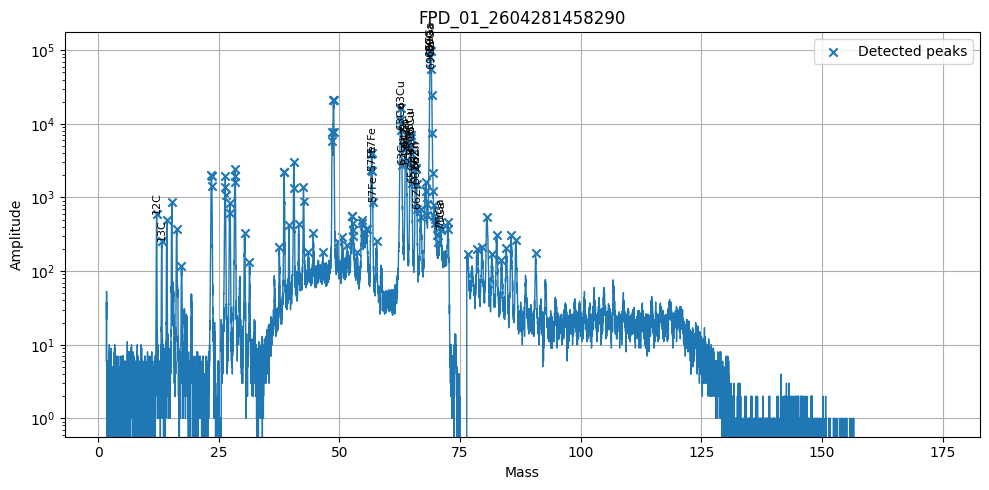

In [9]:
fig, ax, assignments = spec.plot_with_peaks(
    isotope_table=isotopes,
    tolerance=0.2,
    prominence=100,
    distance=5,
    log_y=True,
)

## Load processed FPD image CSV

['Total']
(512, 512)


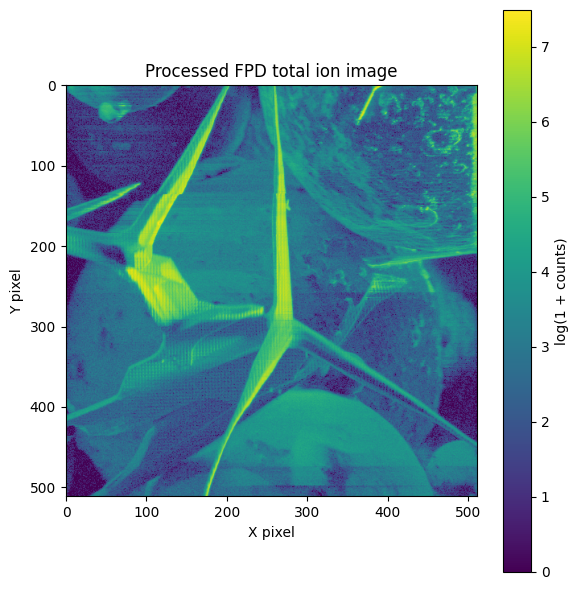

In [10]:
from pymagsims.image import SIMSImage

img = SIMSImage.from_fpd_csv(DATA / "FPD_image2.csv")

print(img.labels())
print(img.total().shape)

plot_ion_image(img.total(), log=True, title="Processed FPD total ion image");